In [ ]:
# %%
# ============================================================
# 1. Physics Defined & Imports
# ============================================================
"""
Physics-Informed Neural Network: Coupled System of ODEs
Governing Equations:
    dx/dt + 2x + y = 0
    dy/dt + x + 2y = 0

Initial Conditions: 
    x(0) = 1
    y(0) = 0

Domain: t ∈ [0, 5]

Analytical Solutions:
    x(t) = 0.5 * (e^(-t) + e^(-3t))
    y(t) = 0.5 * (e^(-3t) - e^(-t))
"""
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
dde.config.set_random_seed(SEED)
import torch
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# %%

In [69]:
# %%
# ============================================================
# 2. SETUP
# ============================================================
dde.config.set_default_float("float64")
print(f"Backend: {dde.backend.backend_name}")

# Initial conditions
x0 = 1.0
y0 = 0.0

# Time domain
t_start = 0.0
t_end = 5.0

print("\n" + "="*60)
print("📊 SYSTEM PARAMETERS")
print("="*60)
print(f"Coupled ODE System:")
print(f"  dx/dt + 2x + y = 0")
print(f"  dy/dt + x + 2y = 0")
print(f"Initial Conditions:")
print(f"  x(0) = {x0}")
print(f"  y(0) = {y0}")
print(f"Time Domain: [{t_start}, {t_end}]")
print("="*60)

# %%

Set the default float type to float64
Backend: pytorch

📊 SYSTEM PARAMETERS
Coupled ODE System:
  dx/dt + 2x + y = 0
  dy/dt + x + 2y = 0
Initial Conditions:
  x(0) = 1.0
  y(0) = 0.0
Time Domain: [0.0, 5.0]


In [70]:
# %%
# ============================================================
# 3. ANALYTICAL SOLUTIONS
# ============================================================
def analytical_x(t):
    """
    Analytical solution for x(t)
    x(t) = 0.5 * (e^(-t) + e^(-3t))
    """
    return 0.5 * (np.exp(-t) + np.exp(-3 * t))

def analytical_y(t):
    """
    Analytical solution for y(t)
    y(t) = 0.5 * (e^(-3t) - e^(-t))
    """
    return 0.5 * (np.exp(-3 * t) - np.exp(-t))

def analytical_solution(t):
    """
    Combined analytical solution
    Returns: [x(t), y(t)]
    """
    x = analytical_x(t)
    y = analytical_y(t)
    return np.hstack((x, y))

# %%

In [71]:
# ============================================================
# 4. DEFINE PROBLEM
# ============================================================
# Time domain: 0 to 5
geom = dde.geometry.TimeDomain(t_start, t_end)

def ode_system(t, output):
    """
    Coupled ODE system residuals
    output[:, 0:1] represents x(t)
    output[:, 1:2] represents y(t)
    
    Returns list of residuals:
        - residual1: dx/dt + 2x + y = 0
        - residual2: dy/dt + x + 2y = 0
    """
    # Extract x and y from network output
    x = output[:, 0:1]
    y = output[:, 1:2]
    
    # Compute derivatives using Jacobian
    # i=0 means derivative of first output (x)
    # i=1 means derivative of second output (y)
    dx_dt = dde.grad.jacobian(output, t, i=0)
    dy_dt = dde.grad.jacobian(output, t, i=1)
    
    # Define residuals according to the equations
    # eq1: dx/dt + 2x + y = 0
    # eq2: dy/dt + x + 2y = 0
    residual1 = dx_dt + 2 * x + y
    residual2 = dy_dt + x + 2 * y
    
    # Return as list of tensors
    return [residual1, residual2]

# Initial condition for x(0) = 1
def ic_x_func(t):
    return x0

ic_x = dde.icbc.IC(
    geom,
    ic_x_func,
    lambda _, on_initial: on_initial,
    component=0  # Apply to x(t)
)

# Initial condition for y(0) = 0
def ic_y_func(t):
    return y0

ic_y = dde.icbc.IC(
    geom,
    ic_y_func,
    lambda _, on_initial: on_initial,
    component=1  # Apply to y(t)
)

# %%

In [72]:
# ============================================================
# 4. GENERATE DATA (WITH NOISY OBSERVATIONS)
# ============================================================

# Generate noisy training observations
observe_t = np.linspace(0, 5, 35).reshape(-1, 1)

# Extract x and y components from analytical solution
observe_xy = analytical_solution(observe_t)
observe_x = observe_xy[:, 0:1]
observe_y = observe_xy[:, 1:2]

# Add 3% noise with different seeds
noise_level = 0.03

np.random.seed(SEED + 1)
noise_x = noise_level * np.std(observe_x) * np.random.randn(35, 1)

np.random.seed(SEED + 2)
noise_y = noise_level * np.std(observe_y) * np.random.randn(35, 1)

observe_x_noisy = observe_x + noise_x
observe_y_noisy = observe_y + noise_y

# Create PointSetBCs for noisy observations
observe_x_bc = dde.icbc.PointSetBC(observe_t, observe_x_noisy, component=0)
observe_y_bc = dde.icbc.PointSetBC(observe_t, observe_y_noisy, component=1)

# Combine all constraints INCLUDING the noisy observations
data = dde.data.TimePDE(
    geom,
    ode_system,
    [ic_x, ic_y, observe_x_bc, observe_y_bc],
    num_domain=1500,      # Collocation points for physics
    num_boundary=50,      # Boundary points (initial condition)
    num_test=100,        # Test points for validation
    solution=analytical_solution,
    train_distribution='pseudo'
)

print(f"\n✅ Hybrid PINN Problem Defined Successfully!")
print(f"   - ODE System: dx/dt + 2x + y = 0, dy/dt + x + 2y = 0")
print(f"   - IC: x(0) = {x0}, y(0) = {y0}")
print(f"   - Noisy observations: {len(observe_t)} points with {noise_level*100}% noise")
print(f"   - Domain (physics) points: {data.num_domain}")
print(f"   - Boundary points: {data.num_boundary}")
print(f"   - Test points: {data.num_test}")


✅ Hybrid PINN Problem Defined Successfully!
   - ODE System: dx/dt + 2x + y = 0, dy/dt + x + 2y = 0
   - IC: x(0) = 1.0, y(0) = 0.0
   - Noisy observations: 35 points with 3.0% noise
   - Domain (physics) points: 1500
   - Boundary points: 50
   - Test points: 100


In [73]:
# 5. BUILD NEURAL NETWORK
# ============================================================
# Architecture: 1 input (time) → 3 hidden layers (128→64→32) → 2 outputs (x,y)
net = dde.nn.FNN([1, 128, 128, 128, 64, 64, 32, 2], "tanh", "Glorot uniform")

In [74]:
# 6. CREATE MODEL
# ============================================================
model = dde.Model(data, net)

In [75]:
# ============================================================
# 7. SET LOSS WEIGHTS (λ parameters) - UPDATED FOR 6 COMPONENTS
# ============================================================
"""
CRITICAL: DeepXDE loss weight configuration for Hybrid PINN (BOTH x & y data)
Loss components (NOW 6!):
  - losses[0]: ODE residual 1 (dx/dt + 2x + y = 0)
  - losses[1]: ODE residual 2 (dy/dt + x + 2y = 0)
  - losses[2]: Initial condition x(0) = 1
  - losses[3]: Initial condition y(0) = 0
  - losses[4]: Data loss x (noisy observations of x)
  - losses[5]: Data loss y (noisy observations of y)  ← NEW!
Total Loss = λ₁*L_ODE1 + λ₂*L_ODE2 + λ₃*L_IC_x + λ₄*L_IC_y + λ₅*L_data_x + λ₆*L_data_y
"""
# Define loss weights (tune these for your problem) - NOW 6 ELEMENTS!
loss_weights = [
    30.0,   # λ_ODE1: First ODE equation weight (dx/dt + 2x + y = 0)
    300.0,   # λ_ODE2: Second ODE equation weight (dy/dt + x + 2y = 0)
    200.0,  # λ_IC_x: Initial condition x(0) = 1
    200.0,  # λ_IC_y: Initial condition y(0) = 0
    50.0,  # λ_data_x: Noisy x observation weight (increased to trust data more)
    50.0   # λ_data_y: Noisy y observation weight (new!)
]
print("\n" + "="*60)
print("📊 HYBRID PINN LOSS WEIGHT CONFIGURATION (BOTH x & y DATA)")
print("="*60)
print(f"λ_ODE1 (dx/dt + 2x + y = 0): {loss_weights[0]}")
print(f"λ_ODE2 (dy/dt + x + 2y = 0): {loss_weights[1]}")
print(f"λ_IC_x (x(0) = {x0}): {loss_weights[2]}")
print(f"λ_IC_y (y(0) = {y0}): {loss_weights[3]}")
print(f"λ_data_x (Noisy x Obs): {loss_weights[4]}")
print(f"λ_data_y (Noisy y Obs): {loss_weights[5]}")  # ← NEW LINE
print("="*60)
print("\n💡 TIP: Increase λ_data_x/y if PINN ignores noisy measurements")
print("         Decrease if PINN overfits to noise")


📊 HYBRID PINN LOSS WEIGHT CONFIGURATION (BOTH x & y DATA)
λ_ODE1 (dx/dt + 2x + y = 0): 30.0
λ_ODE2 (dy/dt + x + 2y = 0): 300.0
λ_IC_x (x(0) = 1.0): 200.0
λ_IC_y (y(0) = 0.0): 200.0
λ_data_x (Noisy x Obs): 50.0
λ_data_y (Noisy y Obs): 50.0

💡 TIP: Increase λ_data_x/y if PINN ignores noisy measurements
         Decrease if PINN overfits to noise


In [76]:
# ============================================================
# 8. TRAIN MODEL WITH LOSS WEIGHTS
# ============================================================
print("\n🔧 Training with Adam Optimizer...")
model.compile(
    "adam",
    lr=0.001,
    decay=("inverse time", 2000, 0.5),
    loss_weights=loss_weights  # ✅ ADD THIS LINE
)
losshistory, train_state = model.train(iterations=5000, display_every=500)

print("\n🔧 Fine-tuning with L-BFGS...")
model.compile(
    "L-BFGS",
    loss_weights=loss_weights  # ✅ ADD THIS LINE TOO
)
losshistory, train_state = model.train(display_every=200)


🔧 Training with Adam Optimizer...
Compiling model...
'compile' took 0.000234 s

Training model...

Step      Train loss                                                      Test loss                                                       Test metric
0         [5.82e-01, 3.92e+01, 2.00e+02, 0.00e+00, 3.82e+00, 1.17e+00]    [5.97e-01, 3.96e+01, 2.00e+02, 0.00e+00, 3.82e+00, 1.17e+00]    []  
500       [1.97e-02, 2.10e-02, 3.73e-05, 1.32e-04, 2.50e-03, 4.07e-04]    [1.44e-02, 1.78e-02, 3.73e-05, 1.32e-04, 2.50e-03, 4.07e-04]    []  
1000      [6.44e-03, 3.25e-03, 1.06e-06, 1.07e-05, 1.67e-03, 2.24e-04]    [6.12e-03, 3.11e-03, 1.06e-06, 1.07e-05, 1.67e-03, 2.24e-04]    []  
1500      [3.06e-01, 2.01e+00, 3.78e-02, 5.78e-04, 6.63e-02, 2.36e-02]    [3.05e-01, 2.02e+00, 3.78e-02, 5.78e-04, 6.63e-02, 2.36e-02]    []  
2000      [2.39e-03, 3.43e-04, 9.06e-09, 1.53e-06, 1.72e-03, 1.79e-04]    [2.43e-03, 3.63e-04, 9.06e-09, 1.53e-06, 1.72e-03, 1.79e-04]    []  
2500      [1.48e-03, 1.44e-04, 4.74

In [77]:
# %%
# ============================================================
# 9. EVALUATE RESULTS
# ============================================================
# Generate dense test points for visualization
t_test = np.linspace(t_start, t_end, 100).reshape(-1, 1)

# Get predictions on dense grid
y_pred = model.predict(t_test)  # Shape: (100, 2)
x_pred = y_pred[:, 0:1]
y_pred_var = y_pred[:, 1:2]

# Get analytical solutions on dense grid
y_exact = analytical_solution(t_test)
x_exact = y_exact[:, 0:1]
y_exact_var = y_exact[:, 1:2]

# ============================================================
# GENERATE 15 TEST POINTS WITH NOISE (for evaluation)
# ============================================================
test_points = 15
t_test_15 = np.linspace(t_start, t_end, test_points).reshape(-1, 1)

# Get exact solution at test points
x_exact_15 = analytical_solution(t_test_15)[:, 0:1]
y_exact_15 = analytical_solution(t_test_15)[:, 1:2]

# Add 3% noise to create test data
np.random.seed(SEED + 1)  # Different seed from training
noise_test = 0.03 * np.std(x_exact_15) * np.random.randn(test_points, 1)
x_test_noisy = x_exact_15 + noise_test

# Generate y_test_noisy with SAME different seed
np.random.seed(SEED + 2)  # Separate seed for y
noise_y_test = 0.03 * np.std(y_exact_15) * np.random.randn(test_points, 1)
y_test_noisy = y_exact_15 + noise_y_test

# Get PINN predictions at test points
y_pred_15 = model.predict(t_test_15)
x_pred_15 = y_pred_15[:, 0:1]
y_pred_15_var = y_pred_15[:, 1:2]

# Calculate errors on 15 test points
absolute_error_15 = np.abs(x_test_noisy - x_pred_15)
relative_error_15 = absolute_error_15 / (np.abs(x_test_noisy) + 1e-10)

# ADD BELOW IT - error for y(t):
absolute_error_y_15 = np.abs(y_test_noisy - y_pred_15_var)
relative_error_y_15 = absolute_error_y_15 / (np.abs(y_test_noisy) + 1e-10)

l2_error_15 = np.linalg.norm(x_test_noisy - x_pred_15) / np.linalg.norm(x_test_noisy)

# Calculate errors on full test set (100 points)
l2_error_x = np.linalg.norm(x_exact - x_pred) / np.linalg.norm(x_exact)
l2_error_y = np.linalg.norm(y_exact_var - y_pred_var) / np.linalg.norm(y_exact_var)
l2_error_total = np.linalg.norm(y_exact - y_pred) / np.linalg.norm(y_exact)

# Check initial conditions
ic_check = model.predict(np.array([[0.0]]))
x_at_0 = ic_check[0, 0]
y_at_0 = ic_check[0, 1]

print("\n" + "="*60)
print("📊 PERFORMANCE METRICS")
print("="*60)
print("\n🔬 On 15 Noisy Test Points:")
print(f"  L2 Relative Error: {l2_error_15:.6f}")
print(f"  Mean Absolute Error: {np.mean(absolute_error_15):.6f}")
print(f"  Mean Relative Error: {np.mean(relative_error_15)*100:.2f}%")
print("\n📈 On Full Test Set (100 points):")
print(f"  L2 Relative Error (x): {l2_error_x:.6f}")
print(f"  L2 Relative Error (y): {l2_error_y:.6f}")
print(f"  L2 Relative Error (total): {l2_error_total:.6f}")
print("\n📍 INITIAL CONDITION CHECK")
print("-"*60)
print(f"x(0) = {x_at_0:.6f} (Target: {x0})")
print(f"y(0) = {y_at_0:.6f} (Target: {y0})")
print("="*60)

# %%


📊 PERFORMANCE METRICS

🔬 On 15 Noisy Test Points:
  L2 Relative Error: 0.023504
  Mean Absolute Error: 0.006110
  Mean Relative Error: 51.16%

📈 On Full Test Set (100 points):
  L2 Relative Error (x): 0.001417
  L2 Relative Error (y): 0.001598
  L2 Relative Error (total): 0.001439

📍 INITIAL CONDITION CHECK
------------------------------------------------------------
x(0) = 0.999991 (Target: 1.0)
y(0) = -0.000012 (Target: 0.0)


In [78]:
# ============================================================
# 10. EXTRACT FINAL LOSSES - UPDATED FOR 6 COMPONENTS
# ============================================================
final_train_losses = model.losshistory.loss_train[-1]  # Now has 6 elements!
print("\n" + "="*60)
print("📉 FINAL TRAINING LOSSES (HYBRID PINN - BOTH x & y DATA)")
print("="*60)
print(f"L_ODE1 (dx/dt + 2x + y = 0): {final_train_losses[0]:.6e}")
print(f"L_ODE2 (dy/dt + x + 2y = 0): {final_train_losses[1]:.6e}")
print(f"L_IC_x (x(0) = 1): {final_train_losses[2]:.6e}")
print(f"L_IC_y (y(0) = 0): {final_train_losses[3]:.6e}")
print(f"L_data_x (Noisy x Obs): {final_train_losses[4]:.6e} ⭐")
print(f"L_data_y (Noisy y Obs): {final_train_losses[5]:.6e} ⭐")  # ← NEW LINE
print("\n📉 WEIGHTED CONTRIBUTIONS")
print("="*60)
weighted = [w * l for w, l in zip(loss_weights, final_train_losses)]  # Now 6 pairs
print(f"λ_ODE1 × L_ODE1: {weighted[0]:.6e}")
print(f"λ_ODE2 × L_ODE2: {weighted[1]:.6e}")
print(f"λ_IC_x × L_IC_x: {weighted[2]:.6e}")
print(f"λ_IC_y × L_IC_y: {weighted[3]:.6e}")
print(f"λ_data_x × L_data_x: {weighted[4]:.6e}")
print(f"λ_data_y × L_data_y: {weighted[5]:.6e}")  # ← NEW LINE
print(f"\nTotal Weighted: {sum(weighted):.6e}")
print("="*60)


📉 FINAL TRAINING LOSSES (HYBRID PINN - BOTH x & y DATA)
L_ODE1 (dx/dt + 2x + y = 0): 2.922867e-05
L_ODE2 (dy/dt + x + 2y = 0): 2.808343e-06
L_IC_x (x(0) = 1): 1.594225e-08
L_IC_y (y(0) = 0): 2.660557e-08
L_data_x (Noisy x Obs): 1.817021e-03 ⭐
L_data_y (Noisy y Obs): 1.539914e-04 ⭐

📉 WEIGHTED CONTRIBUTIONS
λ_ODE1 × L_ODE1: 8.768601e-04
λ_ODE2 × L_ODE2: 8.425030e-04
λ_IC_x × L_IC_x: 3.188451e-06
λ_IC_y × L_IC_y: 5.321115e-06
λ_data_x × L_data_x: 9.085107e-02
λ_data_y × L_data_y: 7.699572e-03

Total Weighted: 1.002785e-01



💾 Results saved to 'hybrid_pinn_coupled_ode_results.png'


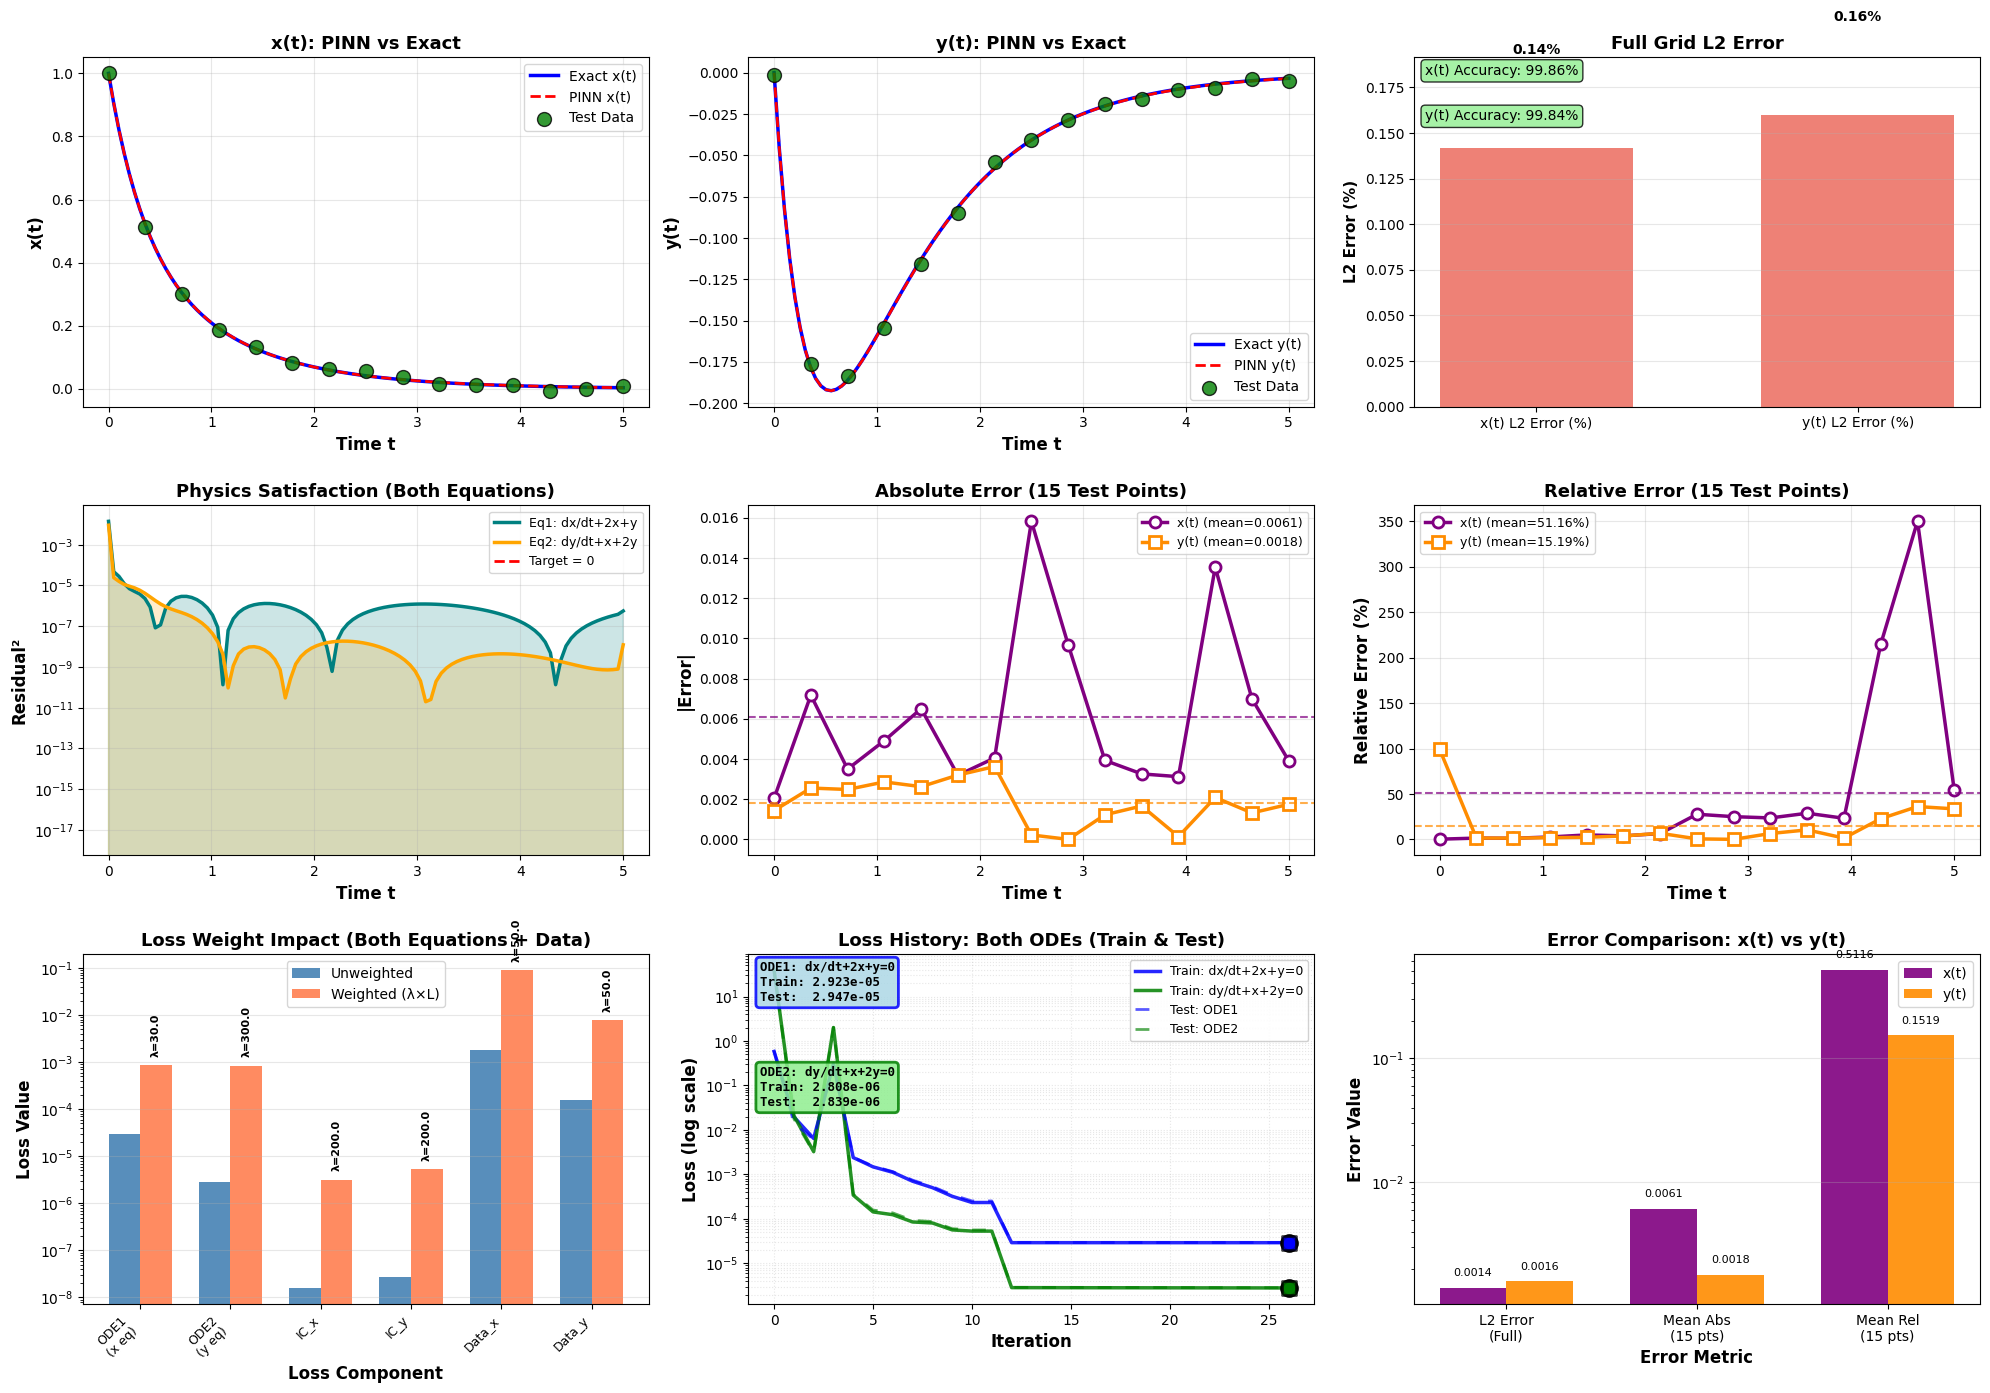

In [79]:
# ============================================================
# 11. FINAL VISUALIZATION - 9 PANEL LAYOUT (CORRECTED)
# ============================================================
fig = plt.figure(figsize=(20, 14))

# ------------------------------------------------------------
# Plot 1: x(t) Solution Comparison
# ------------------------------------------------------------
ax1 = plt.subplot(3, 3, 1)
plt.plot(t_test, x_exact, 'b-', linewidth=2.5, label='Exact x(t)')
plt.plot(t_test, x_pred, 'r--', linewidth=2, label='PINN x(t)')
plt.scatter(t_test_15, x_test_noisy, c='green', s=100, alpha=0.8,
           label='Test Data', zorder=5, edgecolors='black', marker='o')
plt.xlabel('Time t', fontsize=12, fontweight='bold')
plt.ylabel('x(t)', fontsize=12, fontweight='bold')
plt.title('x(t): PINN vs Exact', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# ------------------------------------------------------------
# Plot 2: y(t) Solution Comparison
# ------------------------------------------------------------
ax2 = plt.subplot(3, 3, 2)
plt.plot(t_test, y_exact_var, 'b-', linewidth=2.5, label='Exact y(t)')
plt.plot(t_test, y_pred_var, 'r--', linewidth=2, label='PINN y(t)')

plt.scatter(t_test_15, y_test_noisy, c='green', s=100, alpha=0.8,
           label='Test Data', zorder=5, edgecolors='black', marker='o')
plt.xlabel('Time t', fontsize=12, fontweight='bold')
plt.ylabel('y(t)', fontsize=12, fontweight='bold')
plt.title('y(t): PINN vs Exact', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# ------------------------------------------------------------
# Plot 3: Global L2 Error - BAR CHART (FIXED LAYOUT)
# ------------------------------------------------------------
ax3 = plt.subplot(3, 3, 3)
# Calculate errors for both
l2_error_x_pct = l2_error_x * 100
l2_error_y_pct = l2_error_y * 100
accuracy_x = 100 - l2_error_x_pct
accuracy_y = 100 - l2_error_y_pct

# Create bar chart for L2 errors
metrics = ['x(t) L2 Error (%)', 'y(t) L2 Error (%)']
errors = [l2_error_x_pct, l2_error_y_pct]
bars = ax3.bar(metrics, errors, color=['#e74c3c', '#e74c3c'], alpha=0.7, width=0.6)
ax3.set_ylabel('L2 Error (%)', fontsize=11, fontweight='bold')
ax3.set_title('Full Grid L2 Error', fontsize=13, fontweight='bold')
ax3.set_ylim(0, max(errors) * 1.2)

# Add value labels on bars
for i, (bar, err) in enumerate(zip(bars, errors)):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.05,
             f'{err:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add accuracy text
ax3.text(0.02, 0.98, f'x(t) Accuracy: {accuracy_x:.2f}%', transform=ax3.transAxes,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
ax3.text(0.02, 0.85, f'y(t) Accuracy: {accuracy_y:.2f}%', transform=ax3.transAxes,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
ax3.grid(True, alpha=0.3, axis='y')

# ------------------------------------------------------------
# Plot 4: Physics Residuals for BOTH Equations
# ------------------------------------------------------------
ax4 = plt.subplot(3, 3, 4)
t_physics = np.linspace(t_start, t_end, 100).reshape(-1, 1)
y_physics = model.predict(t_physics)
x_physics = y_physics[:, 0:1]
y_physics_var = y_physics[:, 1:2]

dt = t_physics[1, 0] - t_physics[0, 0]
dx_dt_numeric = np.gradient(x_physics.flatten(), dt)
dy_dt_numeric = np.gradient(y_physics_var.flatten(), dt)

# Compute residuals for BOTH equations
residual1 = dx_dt_numeric + 2 * x_physics.flatten() + y_physics_var.flatten()
residual2 = dy_dt_numeric + x_physics.flatten() + 2 * y_physics_var.flatten()

plt.plot(t_physics, residual1**2, 'teal', linewidth=2.5, label="Eq1: dx/dt+2x+y")
plt.plot(t_physics, residual2**2, 'orange', linewidth=2.5, label="Eq2: dy/dt+x+2y")
plt.axhline(y=0, color='r', linestyle='--', linewidth=2, label='Target = 0')
plt.fill_between(t_physics.flatten(), 0, residual1**2, alpha=0.2, color='teal')
plt.fill_between(t_physics.flatten(), 0, residual2**2, alpha=0.2, color='orange')
plt.xlabel('Time t', fontsize=12, fontweight='bold')
plt.ylabel('Residual²', fontsize=12, fontweight='bold')
plt.title('Physics Satisfaction (Both Equations)', fontsize=13, fontweight='bold')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.yscale('log')

# ------------------------------------------------------------
# Plot 5: Absolute Error on 15 Test Points - BOTH x(t) and y(t)
# ------------------------------------------------------------
ax5 = plt.subplot(3, 3, 5)

# Calculate errors for x(t)
absolute_error_x_15 = np.abs(x_test_noisy - x_pred_15)
mean_error_x_15 = np.mean(absolute_error_x_15)

# Calculate errors for y(t)
y_pred_15_var = y_pred_15[:, 1:2]
absolute_error_y_15 = np.abs(y_test_noisy - y_pred_15_var)
mean_error_y_15 = np.mean(absolute_error_y_15)

plt.plot(t_test_15, absolute_error_x_15, 'purple', linewidth=2.5, marker='o', 
         markersize=8, markerfacecolor='white', markeredgewidth=2, label=f'x(t) (mean={mean_error_x_15:.4f})')
plt.plot(t_test_15, absolute_error_y_15, 'darkorange', linewidth=2.5, marker='s', 
         markersize=8, markerfacecolor='white', markeredgewidth=2, label=f'y(t) (mean={mean_error_y_15:.4f})')

plt.axhline(y=mean_error_x_15, color='purple', linestyle='--', linewidth=1.5, alpha=0.7)
plt.axhline(y=mean_error_y_15, color='darkorange', linestyle='--', linewidth=1.5, alpha=0.7)

plt.xlabel('Time t', fontsize=12, fontweight='bold')
plt.ylabel('|Error|', fontsize=12, fontweight='bold')
plt.title('Absolute Error (15 Test Points)', fontsize=13, fontweight='bold')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)

# ------------------------------------------------------------
# Plot 6: Relative Error on 15 Test Points - BOTH x(t) and y(t)
# ------------------------------------------------------------
ax6 = plt.subplot(3, 3, 6)

# Calculate relative errors
relative_error_x_15 = absolute_error_x_15 / (np.abs(x_test_noisy) + 1e-10)
relative_error_y_15 = absolute_error_y_15 / (np.abs(y_test_noisy) + 1e-10)
mean_rel_error_x_15 = np.mean(relative_error_x_15) * 100
mean_rel_error_y_15 = np.mean(relative_error_y_15) * 100

plt.plot(t_test_15, relative_error_x_15 * 100, 'purple', linewidth=2.5, 
         marker='o', markersize=8, markerfacecolor='white', markeredgewidth=2,
         label=f'x(t) (mean={mean_rel_error_x_15:.2f}%)')
plt.plot(t_test_15, relative_error_y_15 * 100, 'darkorange', linewidth=2.5, 
         marker='s', markersize=8, markerfacecolor='white', markeredgewidth=2,
         label=f'y(t) (mean={mean_rel_error_y_15:.2f}%)')

plt.axhline(y=mean_rel_error_x_15, color='purple', linestyle='--', linewidth=1.5, alpha=0.7)
plt.axhline(y=mean_rel_error_y_15, color='darkorange', linestyle='--', linewidth=1.5, alpha=0.7)

plt.xlabel('Time t', fontsize=12, fontweight='bold')
plt.ylabel('Relative Error (%)', fontsize=12, fontweight='bold')
plt.title('Relative Error (15 Test Points)', fontsize=13, fontweight='bold')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)

# ------------------------------------------------------------
# Plot 7: Loss Weight Impact - UPDATED FOR 6 COMPONENTS
# ------------------------------------------------------------
ax7 = plt.subplot(3, 3, 7)
loss_labels = ['ODE1\n(x eq)', 'ODE2\n(y eq)', 'IC_x', 'IC_y', 'Data_x', 'Data_y']  # ← Now 6 labels!
x_pos = np.arange(len(loss_labels))  # ← Now shape: (6,)
width = 0.35

# Take first 6 elements (should match exactly now)
bars1 = ax7.bar(x_pos - width/2, final_train_losses[:6], width,  # ← Slice to ensure 6
                label='Unweighted', alpha=0.9, color='steelblue')
bars2 = ax7.bar(x_pos + width/2, weighted[:6], width,  # ← Slice to ensure 6
                label='Weighted (λ×L)', alpha=0.9, color='coral')

ax7.set_xlabel('Loss Component', fontsize=12, fontweight='bold')
ax7.set_ylabel('Loss Value', fontsize=12, fontweight='bold')
ax7.set_title('Loss Weight Impact (Both Equations + Data)', fontsize=13, fontweight='bold')
ax7.set_xticks(x_pos)
ax7.set_xticklabels(loss_labels, fontsize=9, rotation=45, ha='right')  # ← Rotate for readability
ax7.set_yscale('log')
ax7.legend(fontsize=10)
ax7.grid(True, alpha=0.3, axis='y')

# Add weight labels (now for 6 bars)
for i, (bar, λ) in enumerate(zip(bars2, loss_weights)):
    h = bar.get_height()
    if h > 0:
        ax7.text(bar.get_x() + bar.get_width()/2, h * 1.5,
                f'λ={λ}', ha='center', va='bottom',
                fontsize=8, fontweight='bold', rotation=90)  # ← Rotate labels

# ------------------------------------------------------------
# Plot 8: Training & Test Loss History for BOTH Equations
# ------------------------------------------------------------
ax8 = plt.subplot(3, 3, 8)

if hasattr(losshistory, 'loss_train') and len(losshistory.loss_train) > 0:
    iterations = np.arange(len(losshistory.loss_train))
    
    # Extract losses for both equations
    train_loss_ode1 = np.array([losses[0] for losses in losshistory.loss_train])
    train_loss_ode2 = np.array([losses[1] for losses in losshistory.loss_train])
    
    # Plot TRAIN losses
    line1, = plt.semilogy(iterations, train_loss_ode1, 'b-', linewidth=2.5, 
                         label='Train: dx/dt+2x+y=0', alpha=0.85)
    line2, = plt.semilogy(iterations, train_loss_ode2, 'g-', linewidth=2.5, 
                         label='Train: dy/dt+x+2y=0', alpha=0.85)
    
    # Plot TEST losses (if available)
    if hasattr(losshistory, 'loss_test') and len(losshistory.loss_test) > 0:
        test_loss_ode1 = np.array([losses[0] for losses in losshistory.loss_test])
        test_loss_ode2 = np.array([losses[1] for losses in losshistory.loss_test])
        
        line3, = plt.semilogy(iterations, test_loss_ode1, 'b--', linewidth=2, 
                             label='Test: ODE1', alpha=0.65, dashes=(5, 5))
        line4, = plt.semilogy(iterations, test_loss_ode2, 'g--', linewidth=2, 
                             label='Test: ODE2', alpha=0.65, dashes=(5, 5))
    
    plt.xlabel('Iteration', fontsize=12, fontweight='bold')
    plt.ylabel('Loss (log scale)', fontsize=12, fontweight='bold')
    plt.title('Loss History: Both ODEs (Train & Test)', fontsize=13, fontweight='bold')
    plt.legend(fontsize=9, loc='upper right', framealpha=0.9)
    plt.grid(True, alpha=0.3, which='both', linestyle=':')
    
    # Add vertical line at Adam→L-BFGS transition
    adam_iters = 5000
    if len(iterations) > adam_iters:
        plt.axvline(x=adam_iters, color='red', linestyle=':', linewidth=2, 
                   alpha=0.5)
        plt.text(adam_iters * 1.02, plt.ylim()[1]*0.3, 'Adam→L-BFGS', 
                rotation=90, va='center', fontsize=8, color='red', 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, 
                         edgecolor='red', linewidth=1.5))
    
    # ========================================================
    # SEPARATE TEXT BOXES FOR EACH EQUATION
    # ========================================================
    
    # Get final values
    final_train_ode1 = train_loss_ode1[-1]
    final_train_ode2 = train_loss_ode2[-1]
    
    # Text box for ODE1 (Blue - Top Left)
    textstr_ode1 = f'ODE1: dx/dt+2x+y=0\n' \
                   f'Train: {final_train_ode1:.3e}'
    
    if hasattr(losshistory, 'loss_test') and len(losshistory.loss_test) > 0:
        final_test_ode1 = test_loss_ode1[-1]
        textstr_ode1 += f'\nTest:  {final_test_ode1:.3e}'
    
    props_ode1 = dict(boxstyle='round', facecolor='lightblue', alpha=0.85, 
                     edgecolor='blue', linewidth=2)
    ax8.text(0.02, 0.98, textstr_ode1, transform=ax8.transAxes, fontsize=9,
            verticalalignment='top', bbox=props_ode1, family='monospace',
            fontweight='bold')
    
    # Text box for ODE2 (Green - Below ODE1)
    textstr_ode2 = f'ODE2: dy/dt+x+2y=0\n' \
                   f'Train: {final_train_ode2:.3e}'
    
    if hasattr(losshistory, 'loss_test') and len(losshistory.loss_test) > 0:
        final_test_ode2 = test_loss_ode2[-1]
        textstr_ode2 += f'\nTest:  {final_test_ode2:.3e}'
    
    props_ode2 = dict(boxstyle='round', facecolor='lightgreen', alpha=0.85, 
                     edgecolor='green', linewidth=2)
    ax8.text(0.02, 0.68, textstr_ode2, transform=ax8.transAxes, fontsize=9,
            verticalalignment='top', bbox=props_ode2, family='monospace',
            fontweight='bold')
    
    # Highlight final convergence points
    plt.scatter([iterations[-1]], [final_train_ode1], 
               s=120, c='blue', marker='o', edgecolors='black', linewidth=2.5, 
               zorder=5, label='_nolegend_')
    plt.scatter([iterations[-1]], [final_train_ode2], 
               s=120, c='green', marker='o', edgecolors='black', linewidth=2.5, 
               zorder=5, label='_nolegend_')
    
    # Add test final points if available
    if hasattr(losshistory, 'loss_test') and len(losshistory.loss_test) > 0:
        plt.scatter([iterations[-1]], [final_test_ode1], 
                   s=100, c='blue', marker='s', edgecolors='black', linewidth=2, 
                   zorder=5, alpha=0.7, label='_nolegend_')
        plt.scatter([iterations[-1]], [final_test_ode2], 
                   s=100, c='green', marker='s', edgecolors='black', linewidth=2, 
                   zorder=5, alpha=0.7, label='_nolegend_')

# ------------------------------------------------------------
# Plot 9: Error Comparison Summary
# ------------------------------------------------------------
ax9 = plt.subplot(3, 3, 9)

metrics = ['L2 Error\n(Full)', 'Mean Abs\n(15 pts)', 'Mean Rel\n(15 pts)']
x_errors = [l2_error_x, np.mean(absolute_error_x_15), np.mean(relative_error_x_15)]
y_errors = [l2_error_y, np.mean(absolute_error_y_15), np.mean(relative_error_y_15)]

x_pos = np.arange(len(metrics))
width = 0.35

bars1 = ax9.bar(x_pos - width/2, x_errors, width, label='x(t)', alpha=0.9, color='purple')
bars2 = ax9.bar(x_pos + width/2, y_errors, width, label='y(t)', alpha=0.9, color='darkorange')

ax9.set_xlabel('Error Metric', fontsize=12, fontweight='bold')
ax9.set_ylabel('Error Value', fontsize=12, fontweight='bold')
ax9.set_title('Error Comparison: x(t) vs y(t)', fontsize=13, fontweight='bold')
ax9.set_xticks(x_pos)
ax9.set_xticklabels(metrics, fontsize=10)
ax9.set_yscale('log')
ax9.legend(fontsize=10)
ax9.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax9.text(bar.get_x() + bar.get_width()/2., height * 1.2,
                f'{height:.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('hybrid_pinn_coupled_ode_results.png', dpi=300, bbox_inches='tight')
print("\n💾 Results saved to 'hybrid_pinn_coupled_ode_results.png'")
plt.show()

In [80]:
# %%
# ============================================================
# 12. FINAL SUMMARY
# ============================================================
def fmt(label, value, width_label=45, width_value=12):
    return f"{label:<{width_label}} : {value:>{width_value}}"

print("\n" + "=" * 70)
print("📋 FINAL SUMMARY".center(70))
print("=" * 70)

# System Information
print("\n" + "═" * 70)
print("PHYSICAL SYSTEM".center(70))
print("═" * 70)
print(fmt("Backend", dde.backend.backend_name))
print(fmt("System Type", "Coupled First-Order ODEs"))
print(fmt("Equation 1", "dx/dt + 2x + y = 0"))
print(fmt("Equation 2", "dy/dt + x + 2y = 0"))
print(fmt("Domain", f"t ∈ [{t_start}, {t_end}]"))
print(fmt("Initial Condition x(0)", f"{x0}"))
print(fmt("Initial Condition y(0)", f"{y0}"))
print("═" * 70)

# Training Points
print("\n" + "═" * 70)
print("TRAINING POINTS CONFIGURATION".center(70))
print("═" * 70)
print(fmt("Physics collocation points", data.num_domain))
print(fmt("Boundary (IC) points", data.num_boundary))
print(fmt("Total training points", data.train_x_all.shape[0]))
print("-" * 70)
print(fmt("Noisy observation points", len(observe_t)))
print(fmt("Training noise level", f"{noise_level*100:.1f}%"))
print("-" * 70)
print(fmt("Test points", test_points))
print(fmt("Test noise level", "3.0%"))
print("═" * 70)

# Neural Network
print("\nNEURAL NETWORK ARCHITECTURE")
print("-" * 70)
print(net)
print("-" * 70)

# Best Model Performance
best_step = np.argmin([sum(l) for l in model.losshistory.loss_test])
best_train = model.losshistory.loss_train[best_step]
best_test = model.losshistory.loss_test[best_step]

print("\n" + "═" * 70)
print("BEST MODEL PERFORMANCE".center(70))
print("═" * 70)
print(fmt("Best iteration", best_step))
print("-" * 70)
print(fmt("Total weighted training loss", f"{sum(best_train):.6e}"))
print(fmt("Train → ODE1 loss", f"{best_train[0]:.6e}"))
print(fmt("Train → ODE2 loss", f"{best_train[1]:.6e}"))
print(fmt("Train → IC_x loss", f"{best_train[2]:.6e}"))
print(fmt("Train → IC_y loss", f"{best_train[3]:.6e}"))
print(fmt("Train → Data_x loss", f"{best_train[4]:.6e}"))
print(fmt("Train → Data_y loss", f"{best_train[5]:.6e}"))
print("-" * 70)
print(fmt("Total weighted test loss", f"{sum(best_test):.6e}"))
print(fmt("Test → ODE1 loss", f"{best_test[0]:.6e}"))
print(fmt("Test → ODE2 loss", f"{best_test[1]:.6e}"))
print(fmt("Test → IC_x loss", f"{best_test[2]:.6e}"))
print(fmt("Test → IC_y loss", f"{best_test[3]:.6e}"))
print(fmt("Test → Data_x loss", f"{best_test[4]:.6e}"))
print(fmt("Test → Data_y loss", f"{best_test[5]:.6e}"))
print("═" * 70)

# Final Losses
print("\n" + "═" * 70)
print("FINAL TRAINING LOSSES".center(70))
print("═" * 70)
print(f"{'Component':<15} {'Unweighted':>15} {'Weighted (λ×L)':>20} {'λ':>8}")
print("-" * 70)
components = ["ODE1", "ODE2", "IC_x", "IC_y" , "Data_x", "Data_y"]
for i, comp in enumerate(components):
    L = final_train_losses[i]
    w = loss_weights[i]
    print(f"{comp:<15} {L:>15.6e} {w*L:>20.6e} {w:>8}")
print("-" * 70)
print(f"{'TOTAL WEIGHTED LOSS':<35}{sum(weighted):>20.6e}")
print("═" * 70)

# Metrics
print("\n📊 METRICS")
print("-" * 70)
print(f"{'Metric':<35} {'Value':>15} {'Target'}")
print("-" * 70)
print(f"{'L2 Error (15 test pts)':<35} {l2_error_15:>15.6f} < 0.10")
print(f"{'L2 Error x(t) (full)':<35} {l2_error_x:>15.6f} < 0.05")
print(f"{'L2 Error y(t) (full)':<35} {l2_error_y:>15.6f} < 0.05")
print(f"{'L2 Error total (full)':<35} {l2_error_total:>15.6f} < 0.05")
print(f"{'Mean Abs Error (15 test)':<35} {np.mean(absolute_error_15):>15.6f} < 0.10")
print(f"{'Mean Rel Error (15 test)':<35} {np.mean(relative_error_15):>15.6f} < 0.20")
print("\n")
print(f"x(0) [should be {x0}]                    {x_at_0:>15.6f} {x0}")
print(f"y(0) [should be {y0}]                    {y_at_0:>15.6f} {y0}")
print("=" * 70)


                           📋 FINAL SUMMARY                            

══════════════════════════════════════════════════════════════════════
                           PHYSICAL SYSTEM                            
══════════════════════════════════════════════════════════════════════
Backend                                       :      pytorch
System Type                                   : Coupled First-Order ODEs
Equation 1                                    : dx/dt + 2x + y = 0
Equation 2                                    : dy/dt + x + 2y = 0
Domain                                        : t ∈ [0.0, 5.0]
Initial Condition x(0)                        :          1.0
Initial Condition y(0)                        :          0.0
══════════════════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════════════════
                    TRAINING POINTS CONFIGURATION                     
═══════════════════════════════════════════════

In [81]:
# %%
# ============================================================
# 13. SAVE MODEL
# ============================================================
model.save("hybrid_pinn_coupled_ode_model")
print("\n💾 Model saved to 'hybrid_pinn_coupled_ode_model/'")

config = {
    'loss_weights': loss_weights,  # Now has 6 elements
    'architecture': [1, 128, 128, 64, 32, 2],  # Fixed: match your net
    'activation': 'tanh',
    'system_equations': {
        'ode1': 'dx/dt + 2x + y = 0',
        'ode2': 'dy/dt + x + 2y = 0'
    },
    'initial_conditions': {'x0': x0, 'y0': y0},
    'domain': {'t_start': t_start, 't_end': t_end},
    'noise_config': {
        'training_noise_level': noise_level,
        'test_noise_level': 0.03,
        'num_training_obs': len(observe_t),
        'num_test_points': test_points,
        'observations_for': ['x_and_y']  # ← Add this
    },
    'performance': {
        'l2_error_test_15': float(l2_error_15),
        'l2_error_x': float(l2_error_x),
        'l2_error_y': float(l2_error_y),
        'l2_error_total': float(l2_error_total),
        'mean_rel_error_x': float(np.mean(relative_error_x_15)),  # ← Add
        'mean_rel_error_y': float(np.mean(relative_error_y_15))   # ← Add
    },
    'training_iterations': len(model.losshistory.loss_train)
}

import json
with open('hybrid_pinn_coupled_ode_config.json', 'w') as f:
    json.dump(config, f, indent=4)
print("💾 Configuration saved to 'hybrid_pinn_coupled_ode_config.json'")

print("\n✅ HYBRID PINN TRAINING COMPLETE FOR COUPLED ODE SYSTEM!")


💾 Model saved to 'hybrid_pinn_coupled_ode_model/'
💾 Configuration saved to 'hybrid_pinn_coupled_ode_config.json'

✅ HYBRID PINN TRAINING COMPLETE FOR COUPLED ODE SYSTEM!
